

# Підготовка даних до аналізу






<h2>Мета</h2>

Ознайомитись з методикою первинної обробки даних. Після завершення цієї лабораторної роботи ви зможете:

* Досліджувати структуру завантажених даних
* Виправляти формати даних
* Знаходити та заповнювати пропуски в даних
* Знаходити викиди та некоректні значення
* Будувати прості візуалізації




<a name="task"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

# <h1 id="task">Завдання, що оцінюються </h1>

</div>





1. Скачати дані із файлу, записати у dataframe. Дослідити структуру даних.
2. Виправити помилки в даних.
3. Побудувати діаграми розмаху та гістограми.
4. Заповнити пропуски.
5. Додати стовпчик із щільністю населення.



<a name="task1"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task1">Завдання  #1: </h2>

<p>Дослідити структуру даних</p>
</div>


Для того, щоб працювати з файлами, які зберігаються у хмарному сховищі, необхідно надати середовищу Google Colab доступ до Google Диску.

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



Наступним кроком імпортуємо бібліотеку Pandas, яка є основним інструментом для маніпуляцій з даними. Оскільки вихідний файл Data2.csv має специфічне кодування та розділювачі, ми вказуємо параметри encoding='cp1252' та sep=';' для коректного відображення символів і структури таблиці.

In [27]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/python1/Data2.csv', encoding='cp1252', sep=';')

<details><summary>Натисніть тут, щоб побачити підказку</summary>

```python
DATA_PATH = 'data/Data2.csv'

# Зчитуємо файл із заданим розділяючим символом ";"
df = pd.read_csv(DATA_PATH, sep=';')

'''
Зауваження: попередній код зчитування з файлу підходить для
файлів з кодуванням utf-8. Проте файл Data2.csv спочатку мав інше
кодування. Дане кодування потрібно вказати в якості параметру:
    
'''

df = pd.read_csv(DATA_PATH, sep=';', encoding='cp1252')


```
</details>




Досліджую структуру даних


Після завантаження необхідно перевірити правильність зчитування даних. Використовую метод head(), щоб переглянути перші рядки таблиці, та info(), щоб проаналізувати типи даних у кожному стовпці та виявити можливі пропуски.

In [28]:
df.head(10)

,Country Name,Region,GDP per capita,Populatiion,CO2 emission,Area
0,Afghanistan,South Asia,"561,7787463",34656032.0,"9809,225",652860
1,Albania,Europe & Central Asia,"4124,98239",2876101.0,"5716,853",28750
2,Algeria,Middle East & North Africa,"3916,881571",40606052.0,"145400,217",2381740
3,American Samoa,East Asia & Pacific,"11834,74523",55599.0,NaN,200
4,Andorra,Europe & Central Asia,"36988,62203",77281.0,"462,042",470
5,Angola,Sub-Saharan Africa,"3308,700233",28813463.0,"34763,16",1246700
6,Antigua and Barbuda,Latin America & Caribbean,"14462,17628",100963.0,"531,715",440
7,Argentina,Latin America & Caribbean,"12440,32098",43847430.0,"204024,546",2780400
8,Armenia,Europe & Central Asia,"3614,688357",2924816.0,"5529,836",29740
9,Aruba,Latin America & Caribbean,NaN,104822.0,"872,746",180


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    217 non-null    object 
 1   Region          217 non-null    object 
 2   GDP per capita  190 non-null    object 
 3   Populatiion     216 non-null    float64
 4   CO2 emission    205 non-null    object 
 5   Area            216 non-null    object 
dtypes: float64(1), object(5)
memory usage: 10.3+ KB


Для отримання повної статистичної картини набору даних використовую метод describe. Параметр include='all' дозволяє проаналізувати не лише числові показники, а й текстові дані, відображаючи кількість унікальних значень та найбільш частотні записи.

In [30]:
df.describe(include='all')

,Country Name,Region,GDP per capita,Populatiion,CO2 emission,Area
count,217,217,190,2.160000e+02,205,216
unique,217,7,190,NaN,202,212
top,Afghanistan,Europe & Central Asia,"561,7787463",NaN,"495,045",460
freq,1,58,1,NaN,2,3
mean,NaN,NaN,NaN,4.338952e+07,NaN,NaN
std,NaN,NaN,NaN,1.879574e+08,NaN,NaN
min,NaN,NaN,NaN,1.109700e+04,NaN,NaN
25%,NaN,NaN,NaN,7.900265e+05,NaN,NaN
50%,NaN,NaN,NaN,6.318988e+06,NaN,NaN
75%,NaN,NaN,NaN,2.380373e+07,NaN,NaN


Перегляд переліку назв усіх стовпців необхідний для перевірки коректності заголовків. Це дозволяє виявити зайві пробіли або орфографічні помилки, які можуть заважати подальшому зверненню до даних.

In [31]:
df.columns

Index(['Country Name', 'Region', 'GDP per capita', 'Populatiion',
       'CO2 emission', 'Area'],
      dtype='object')

Одним із найважливіших етапів дослідження є виявлення пропущених значень. Використання комбінації методів isna() та sum() дозволяє швидко підрахувати кількість порожніх клітинок у кожному стовпці, що є важливим для прийняття рішення про подальше очищення даних.

In [32]:
df.isna().sum()

,0
Country Name,0
Region,0
GDP per capita,27
Populatiion,1
CO2 emission,12
Area,1


Оскільки такі показники, як площа країни чи її населення, фізично не можуть бути меншими за нуль, було проведено перевірку на наявність від'ємних значень.

In [33]:
df.apply(lambda col: col.astype(str).str.startswith('-').any(), axis=0)

,0
Country Name,False
Region,False
GDP per capita,True
Populatiion,False
CO2 emission,False
Area,True


Щоб перевірити дані на наявність викидів, шукаю запис із максимальним значенням у певній категорії. Зокрема, пошук країни з найбільшим населенням дозволяє виявити потенційні помилки у розрядності чисел (наприклад, аномальні показники для невеликих країн).

In [34]:
df.loc[df['Populatiion'].idxmax()]

,108
Country Name,Latvia
Region,Europe & Central Asia
GDP per capita,"14071,02723"
Populatiion,1960424000.0
CO2 emission,"6974,634"
Area,64490


Бачу наступні проблеми в даних:
1. Ознаки GDP per capita, CO2 emission та Area мають тип object, хоча є кількісними показниками. Це унеможливлює проведення математичних розрахунків, оскільки числа сприймаються системою як рядки тексту.
2. Стовпець, що відповідає за кількість населення, має некоректну назву Populatiion (із зайвою літерою «i»). Це може спричинити помилки при зверненні до стовпця за його назвою в коді.
3. Наявні від’ємні значення в ознаках GDP per capita та Area.
4. Значення популяції для Латвії є некоректним.
5. Є пропущені значення в ознаках GDP per capita, Population, CO2 emission.


<a name="task2"></a> <div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task2"> Завдання  #2: </h2>

<p>Виправити помилки в даних</p>
</div>


<b>Проблема 1. Неправильні назви</b>
<p>
    Використаю метод rename для виправлення орфографічної помилки у назві стовпця Populatiion (заміню на Population).
</p>
<p>   Перевіряю результат.</p>

In [35]:
df = df.rename(columns={'Populatiion': 'Population'})
df.columns

Index(['Country Name', 'Region', 'GDP per capita', 'Population',
       'CO2 emission', 'Area'],
      dtype='object')

<b>Проблема 2. Неправильні типи даних</b>
<p>
    Проаналізувавши df.info(), я бачу, що стовпці GDP per capita, CO2 emission та Area мають тип object замість float. Причиною є використання коми як роздільника десяткової частини числа, тоді як Python очікує крапку.
</p>
<p>Для виправлення зроблю наступне:<br>
1. Виберу проблемні стовпці.<br>
2. Заміню в них усі коми на крапки за допомогою методу str.replace(',', '.').<br>
3. Конвертую дані у числовий формат за допомогою pd.to_numeric.
</p>
<p>   Перевіряю результат.</p>

In [36]:
cols_to_fix = ['GDP per capita', 'CO2 emission', 'Area']

for col in cols_to_fix:
    # errors='coerce' перетворить будь-яке "сміття", яке не є числом, на NaN
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce')

print(df.dtypes)

Country Name       object
Region             object
GDP per capita    float64
Population        float64
CO2 emission      float64
Area              float64
dtype: object


<b>Проблема 3. Неправильні значення (занадто великі або занадто малі)</b>
<p>
    Для виправлення від'ємних значень у стовпцях Area та GDP per capita я ввізьму ці числа за модулем (функція abs()), припускаючи, що це помилка знаку при введенні.<br>
    Населення Латвії вказано як приблизно 1.9 млрд, що у 1000 разів перевищує реальне. Це помилка розрядності, тому я поділю це значення на 1000.
</p>
<p>   Перевіряю результат.
</p>

In [37]:
cols_with_negatives = ['Area', 'GDP per capita']
for col in cols_with_negatives:
    df[col] = df[col].abs()

latvia_mask = (df['Country Name'] == 'Latvia') & (df['Population'] > 100000000)
if latvia_mask.any():
    df.loc[latvia_mask, 'Population'] = df.loc[latvia_mask, 'Population'] / 1000
    print("Населення Латвії виправлено.")

print(f"Мінімальна площа: {df['Area'].min()}")
print(f"Населення Латвії: {df.loc[df['Country Name'] == 'Latvia', 'Population'].values[0]}")

Населення Латвії виправлено.
Мінімальна площа: 0.0
Населення Латвії: 1960424.0


**Додаткова перевірка на логічну цілісність:**
у стовпцях Area, Population та GDP per capita нуль є технічною помилкою. Я заміню всі нулі на NaN, щоб на наступному етапі вони були автоматично заповнені медіаною разом з іншими пропущеними значеннями. Це також може запобігти помилці ділення на нуль при розрахунку.

In [38]:
import numpy as np

cols_to_check_zeros = ['Area', 'Population', 'GDP per capita']

for col in cols_to_check_zeros:
    df[col] = df[col].replace(0, np.nan)

print(f"Мінімальна площа: {df['Area'].min()}")

Мінімальна площа: 2.0


<a name="task3"></a>
 <div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task5"> Завдання  #3: </h2>

<p>Побудувати діаграми розмаху та гістограми</p>
</div>


Для побудови графіків скористайтесь бібліотекою Matplotlib. Спробуйте погратись з кольорами, розмірами та підписами.


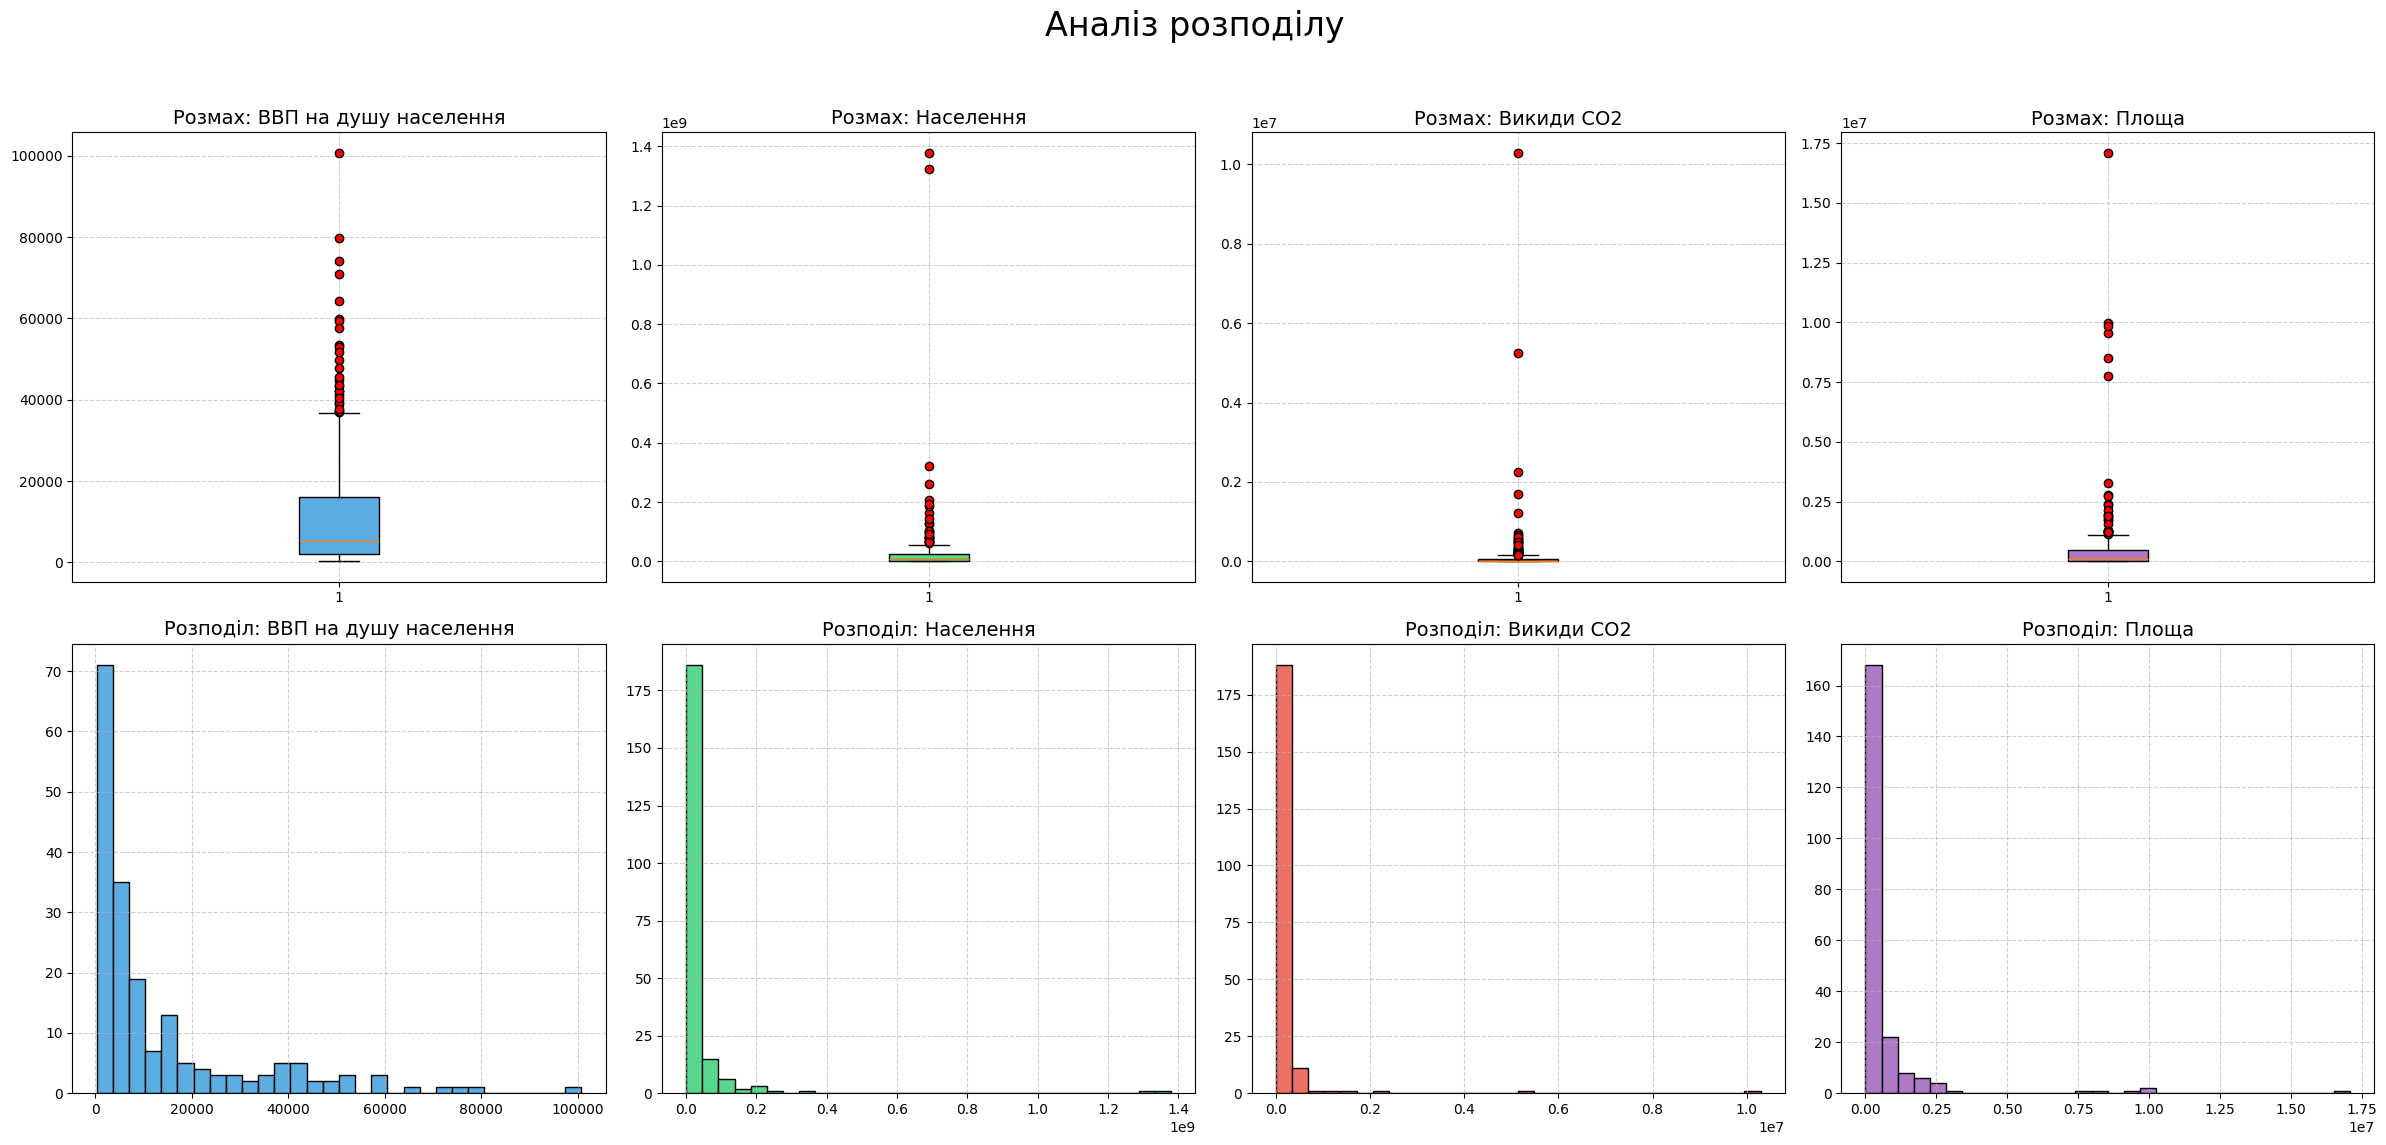

In [39]:
import matplotlib.pyplot as plt

# налаштування розміру
fig, axs = plt.subplots(2, 4, figsize=(24, 12))
fig.suptitle('Аналіз розподілу', fontsize=24)

cols = ['GDP per capita', 'Population', 'CO2 emission', 'Area']
colors = ['#5DADE2', '#58D68D', '#EC7063', '#AF7AC5']
titles = ['ВВП на душу населення', 'Населення', 'Викиди CO2', 'Площа']

for i, col in enumerate(cols):
    # діаграми розмаху (boxplots)
    axs[0, i].boxplot(df[col].dropna(), patch_artist=True,
                      boxprops=dict(facecolor=colors[i]),
                      flierprops=dict(marker='o', markerfacecolor='red', markersize=6)) # червоні точки це викиди

    axs[0, i].set_title(f'Розмах: {titles[i]}', fontsize=14)
    axs[0, i].grid(True, linestyle='--', alpha=0.6)

    # гістограми
    axs[1, i].hist(df[col].dropna(), bins=30, color=colors[i], edgecolor='black')
    axs[1, i].set_title(f'Розподіл: {titles[i]}', fontsize=14)
    axs[1, i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

<details><summary>Натисніть тут, щоб побачити підказку</summary>

```python
# Імпортуємо бібліотеку Matplotlib
import matplotlib.pyplot as plt
    
# діаграми розмаху для "GDP per capita", "Population", "CO2 emission" та "Area"

fig, axs = plt.subplots(1, 4, figsize=(16, 4))

fig.suptitle('Діаграми розмаху', fontsize=16)

axs[0].set_title('GDP per capita')
axs[0].boxplot(df['GDP per capita'])

axs[1].set_title('Population')
axs[1].boxplot(df['Population'])

axs[2].set_title('CO2 emission')
axs[2].boxplot(df['CO2 emission'])

axs[3].set_title('Area')
axs[3].boxplot(df['Area'])

plt.show()

```
</details>




<a name="task4"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task3"> Завдання  #4: </h2>
<b>Проблема 4. Пропущені значення </b>
<p>Візуалізації з попереднього завдання чітко демонструють, що розподіл даних у всіх числових стовпцях є асиметричним (правостороння асиметрія) і містить значну кількість викидів.</p>
</div>


Заповнювати пропуски для ознак GDP per capita, Population, CO2 emission та Area буду медіаною, тому що побудовані графіки показали, що ці дані мають асиметричний розподіл (правосторонню асиметрію) та містять значні викиди. У таких випадках середнє арифметичне дає некоректні, зміщені результати, а медіана є стійкою до викидів і краще відображає реальний центр даних.

In [40]:
cols_to_fix = ['GDP per capita', 'Population', 'CO2 emission', 'Area']

for col in cols_to_fix:
    if col in df.columns:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Пропуски в '{col}' заповнено медіаною: {median_val}")
    else:
        print(f"Увага: Стовпець '{col}' не знайдено.")

Пропуски в 'GDP per capita' заповнено медіаною: 5235.3085465
Пропуски в 'Population' заповнено медіаною: 6221590.5
Пропуски в 'CO2 emission' заповнено медіаною: 9108.828
Пропуски в 'Area' заповнено медіаною: 93030.0


Досліджую структуру даних, чи всі пропуски заповнено


In [41]:
print(df.isna().sum())

Country Name      0
Region            0
GDP per capita    0
Population        0
CO2 emission      0
Area              0
dtype: int64


 <a name="task5"></a>
 <div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task4"> Завдання  #5: </h2>

<p>Додати стовпчик із щільністю населення</p>
</div>


Щільність населення розрахую по формулі $$ \text{Population density} = \frac{\text{Population}}{\text{Area}} $$ і додам у новий стовпчик з відповідною назвою.


In [42]:
df['Population density'] = df['Population'] / df['Area']
df.head(5)

,Country Name,Region,GDP per capita,Population,CO2 emission,Area,Population density
0,Afghanistan,South Asia,561.778746,34656032.0,9809.225,652860.0,53.083405
1,Albania,Europe & Central Asia,4124.982390,2876101.0,5716.853,28750.0,100.038296
2,Algeria,Middle East & North Africa,3916.881571,40606052.0,145400.217,2381740.0,17.048902
3,American Samoa,East Asia & Pacific,11834.745230,55599.0,9108.828,200.0,277.995000
4,Andorra,Europe & Central Asia,36988.622030,77281.0,462.042,470.0,164.427660


<a name="task6"></a>
 <div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task6"> Додаткове завдання: </h2>

<p>Дайте відповіді на питання</p>
</div>



1. Яка країна має найменшу площу?
2. Знайдіть країну з найбільшою щільністю населення у світі? У Європі та центральній Азії?
3. Яка країна має найбільший ВВП на людину (GDP per capita)?
4. Покажіть топ 5 країн та 5 останніх країн по ВВП на людину.



<details><summary>Натисніть тут, щоб побачити підказку</summary>
    
Скористайтесь методами <code>loc()</code> для повернення зрізу датафрейму, <code>idxmax()</code> для повернення номера рядка з найбільшим значенням якогось показника у стовпці та <code>idxmin()</code> для повернення номера рядка з найменшим значенням якогось показника у стовпці
    
```python
df.loc[df['GDP per capita'].idxmax()]

```
    
Гарно оформити виведення інформації допоможе <code>print()</code>  
```python
print('\n' + df.loc[df['GDP per capita'].idxmax(), 'Country Name'] + ' має найбільший ВВП на людину')
```   
  
</details>


In [43]:
# 1. Яка країна має найменшу площу?
min_area_country = df.loc[df['Area'].idxmin()]
print(f"1. Країна з найменшою площею: {min_area_country['Country Name']} ({min_area_country['Area']} кв.км)")

# 2. Країна з найбільшою щільністю населення
# у світі
max_density_world = df.loc[df['Population density'].idxmax()]
print(f"2a. Найбільша щільність у світі: {max_density_world['Country Name']} ({max_density_world['Population density']:.2f} чол/кв.км)")

# У Європі та центральній Азії
europe_data = df[df['Region'] == 'Europe & Central Asia']
max_density_europe = europe_data.loc[europe_data['Population density'].idxmax()]
print(f"2b. Найбільша щільність у Європі: {max_density_europe['Country Name']} ({max_density_europe['Population density']:.2f} чол/кв.км)")

# 3. Яка країна має найбільший ВВП на людину?
max_gdp_country = df.loc[df['GDP per capita'].idxmax()]
print(f"3. Найбільший ВВП на людину: {max_gdp_country['Country Name']} (${max_gdp_country['GDP per capita']:.2f})")

# 4. Топ 5 і останні 5 країн по ВВП
print("\n4. Топ-5 країн за ВВП:")
display(df.nlargest(5, 'GDP per capita')[['Country Name', 'GDP per capita']])

print("\n4. Останні 5 країн за ВВП:")
display(df.nsmallest(5, 'GDP per capita')[['Country Name', 'GDP per capita']])

1. Країна з найменшою площею: Monaco (2.0 кв.км)
2a. Найбільша щільність у світі: Macao SAR, China (20203.53 чол/кв.км)
2b. Найбільша щільність у Європі: Monaco (19249.50 чол/кв.км)
3. Найбільший ВВП на людину: Luxembourg ($100738.68)

4. Топ-5 країн за ВВП:


,Country Name,GDP per capita
115,Luxembourg,100738.68420
188,Switzerland,79887.51824
116,"Macao SAR, China",74017.18471
146,Norway,70868.12250
92,Ireland,64175.43824



4. Останні 5 країн за ВВП:


,Country Name,GDP per capita
31,Burundi,285.727442
119,Malawi,300.307665
134,Mozambique,382.069330
37,Central African Republic,382.213174
118,Madagascar,401.742270


Збережіть дані у новий файл 'clean_data.csv':


In [44]:
from google.colab import files

# зберігаємо файл (створюємо його в пам'яті Colab)
df.to_csv('Data2_clean.csv', index=False)

# завантажуємо на комп'ютер
files.download('Data2_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<h2>Виконала студентка групи ІП-44  <br>Бідюк Марія</h2>
